# Antes de cargar las librerias, hay que instalarlas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Cargamos el data set que deseamos análizar

In [2]:
dataset = pd.read_csv('datasets/iris/iris.data', header=None)
dataset.head()

,0,1,2,3,4
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


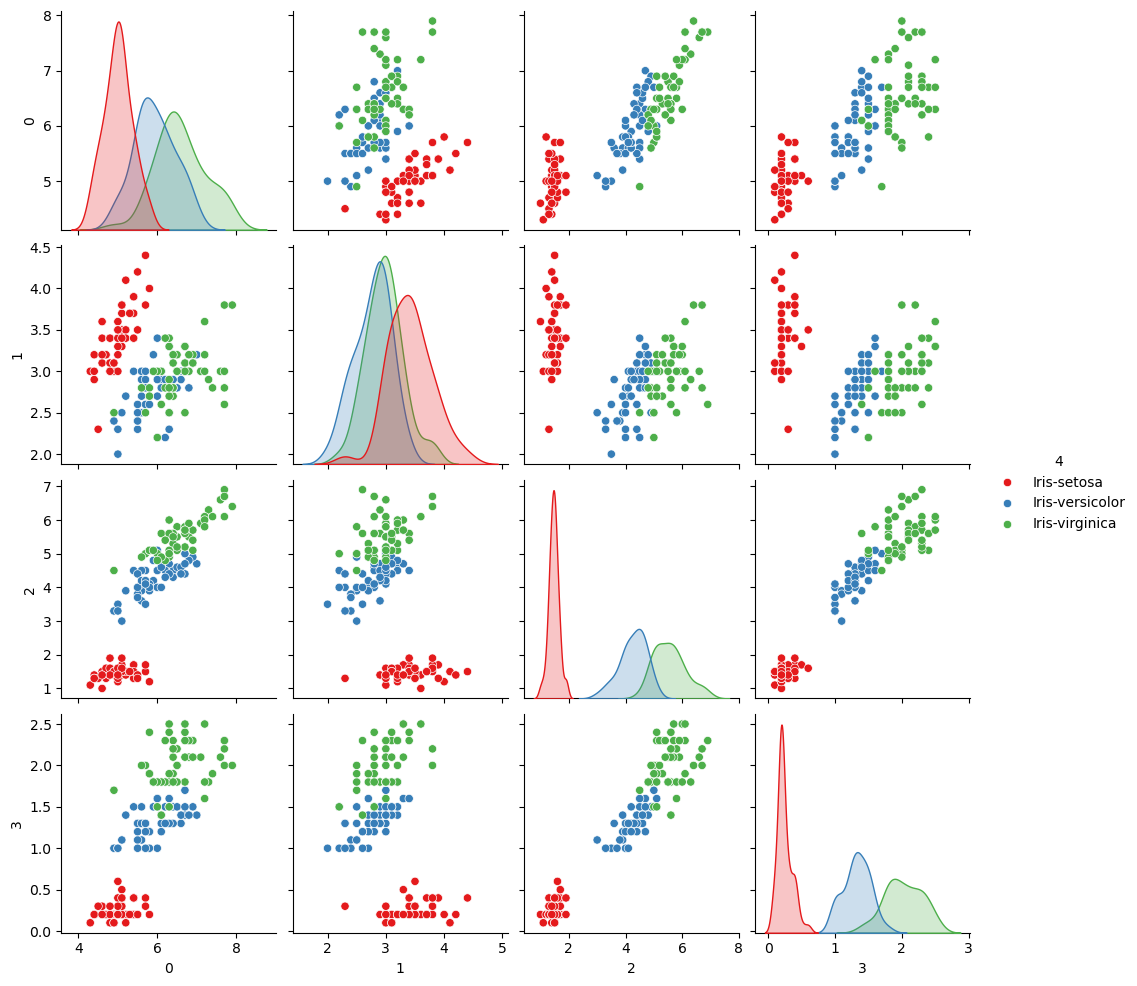

In [3]:
# 0 es el target en este dataset
sns.pairplot(dataset,hue=4,palette="Set1") 
plt.show()

In [4]:
# en este dataset el ultimo atributo es el target.
target = dataset[4].copy()
# de 0 - a n_clases 
target = target.map({"Iris-setosa":0,"Iris-versicolor":1,"Iris-virginica":2}).to_numpy()
target.shape

(150,)

In [5]:
atributos = dataset.iloc[:,:-1].copy()
atributos = atributos.to_numpy().copy()
atributos.shape


(150, 4)

### Generamos el mejor numero de reglas para el  FIS inicial en  base a los datos

In [6]:
from utils import  CrearFISInicial, GuardarFIS
from utils import OneHotEncode, confusion_matrix, PrintLogLevel
import torch # tensores y demás de pytorch
from sklearn.model_selection import train_test_split
#
from torch.optim import Adam
from anfislm.V2_Anfis import LevenberMaquardtOpt, train_nfs, RLANFISBuilder, Optimizador


Dispositivos disponibles: 0 CUDA,  True MPS
Cargando FIS
Entradas: 4 Salidas: 3 Reglas:3
sigma: torch.Size([4, 3])
centro: torch.Size([4, 3])
theta: torch.Size([3, 3])
LBM -> mps
[INFO] Inputs: torch.Size([150, 4]) , Outputs: torch.Size([150, 3])
[ERROR] [86] El modelo llego a las mu maximas 1.0E+20 >= 1.0E+20(True)
[ERROR] [86] con un loss de 2.061637878
[WARNING] Reglas: 3, Loss: 2.061637878
Cargando FIS
Entradas: 4 Salidas: 3 Reglas:4
sigma: torch.Size([4, 4])
centro: torch.Size([4, 4])
theta: torch.Size([4, 3])
LBM -> mps
[INFO] Inputs: torch.Size([150, 4]) , Outputs: torch.Size([150, 3])
[ERROR] [100] El modelo llego a las mu maximas 1.0E+20 >= 1.0E+20(True)
[ERROR] [100] con un loss de 2.148901701
[WARNING] Reglas: 4, Loss: 2.148901701
Cargando FIS
Entradas: 4 Salidas: 3 Reglas:5
sigma: torch.Size([4, 5])
centro: torch.Size([4, 5])
theta: torch.Size([5, 3])
LBM -> mps
[INFO] Inputs: torch.Size([150, 4]) , Outputs: torch.Size([150, 3])
[WARNING] Reglas: 5, Loss: 1.978150725
Cargan

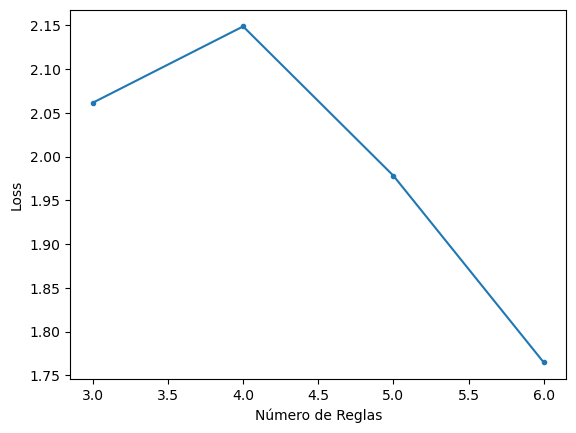

In [7]:
# gpu: cuda si nvidia, mps si mac, cpu si nada de eso
print("Dispositivos disponibles:", torch.cuda.device_count(), "CUDA, ", torch.backends.mps.is_available(), "MPS")
device= "mps"
n_in = 4 #atributos
n_out = 3 #clases

x_todo = torch.tensor(atributos, device=torch.device(device), dtype=torch.float32)
# para clasificación hay que onehot encode el target
# olvide quitar que solo funcione con tensores
target_tensor = torch.tensor(target, device=torch.device(device), dtype=torch.float32)
target_oh = OneHotEncode(target_tensor,n_out)


hist = {
    "reglas":[],
    "fis_st":[],
    "loss":[]
    }
for reglas in range(n_out,n_out*2+1):
    n_reglas = reglas 

    #atributos debe ser un pandas.Dataframe,
    #el target_oh debe ser un pandas.Dataframe 
    #se me fue y no cambie la interfaz
    fis,fis_str = CrearFISInicial("iris_temp",
                              atributos,
                              pd.DataFrame(target_oh.cpu().numpy()),
                              n_reglas)

    # crear modelo temporal
    modelo = RLANFISBuilder() \
         .AddFIS(fis_str) \
         .AddInputs(n_in) \
         .AddOutputs(n_out) \
         .AddRules(n_reglas) \
         .AddMuStats(0.1,10,1e20)\
         .AddValMaxFails(20) \
         .AddOptimizador(LevenberMaquardtOpt)\
         .AddTipoProblema("clasificacion")\
         .AddDevice(device) \
         .Build()
    
    #entrenar temporal
    historial_loss = train_nfs(
                        modelo, # modelo a usar
                        x_todo, target_oh, # datos de entrenamiento
                        epochs=100, # numero de iteraciones
                        tolerancia=1e-8, # error mínimo
                        debug=True
                )
    PrintLogLevel("WARNING",f"Reglas: {reglas}, Loss: {historial_loss[-1]:.9f}")
    hist["reglas"].append(reglas) 
    hist["fis_st"].append(fis_str)
    hist["loss"].append(historial_loss[-1])

# ploteamos
plt.plot(hist["reglas"], hist["loss"],".-")
plt.xlabel("Número de Reglas")
plt.ylabel("Loss")
plt.show()


## Creamos el modelo

### Entrenamiento

Cargando FIS
Entradas: 4 Salidas: 3 Reglas:6
sigma: torch.Size([4, 6])
centro: torch.Size([4, 6])
theta: torch.Size([6, 3])
LBM -> mps
[INFO] Inputs: torch.Size([90, 4]) , Outputs: torch.Size([90, 3])
[ERROR] [103] El modelo llego a las mu maximas 1.0E+21 >= 1.0E+20(True)
[ERROR] [103] con un loss de 1.801955104
[INFO] Loss: 1.8019551038742065


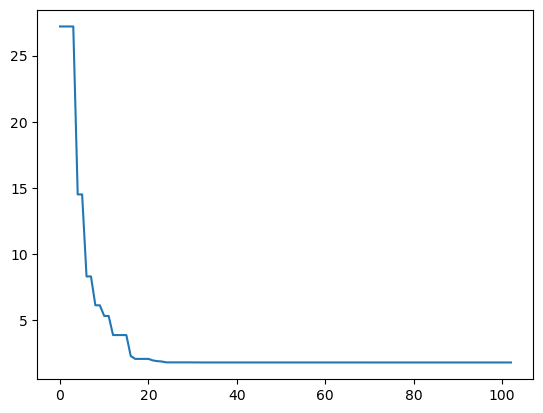

In [8]:
por_test =0.4
val_size = por_test/2
x_train,x_temp,y_train, y_temp = train_test_split(atributos,target,test_size=por_test) 
x_test, x_val, y_test, y_val = train_test_split(x_temp,y_temp,test_size=val_size)

#se ocupan que sean tensores
x_train_tensor = torch.from_numpy(x_train).float().to(torch.device(device))
x_test_tensor = torch.from_numpy(x_test).float().to(torch.device(device))
x_val_tensor = torch.from_numpy(x_val).float().to(torch.device(device))
y_train_tensor = torch.tensor(y_train, device=torch.device(device), dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, device=torch.device(device), dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, device=torch.device(device), dtype=torch.float32)

#clasificación onehot encode
y_train_oh = OneHotEncode(y_train_tensor,n_out)
y_test_oh = OneHotEncode(y_test_tensor,n_out)
y_val_oh = OneHotEncode(y_val_tensor,n_out)



#mejores reglas
b_reglas = hist["reglas"][np.argmin(hist["loss"])]

fis,fis_str = CrearFISInicial("iris",
                              pd.DataFrame(x_train),
                              pd.DataFrame(y_train_oh.cpu().numpy()),
                              b_reglas)
# modelo
modelo = RLANFISBuilder() \
         .AddFIS(fis_str) \
         .AddInputs(n_in) \
         .AddOutputs(n_out) \
         .AddRules(b_reglas) \
         .AddMuStats(0.1,10,1e20)\
         .AddValMaxFails(20) \
         .AddOptimizador(LevenberMaquardtOpt)\
         .AddTipoProblema("clasificacion")\
         .AddDevice(device) \
         .Build() 


# entrenar
historial_loss = train_nfs(
                        modelo, # modelo a usar
                        x_train_tensor, y_train_oh, # datos de entrenamiento
                        epochs=1000, # numero de iteraciones
                        tolerancia=1e-8, # error mínimo
            )
PrintLogLevel("INFO",f"Loss: {historial_loss[-1]}")
plt.plot(historial_loss)
GuardarFIS("iris__final",fis,modelo)

## Graficar

torch.Size([48, 3])


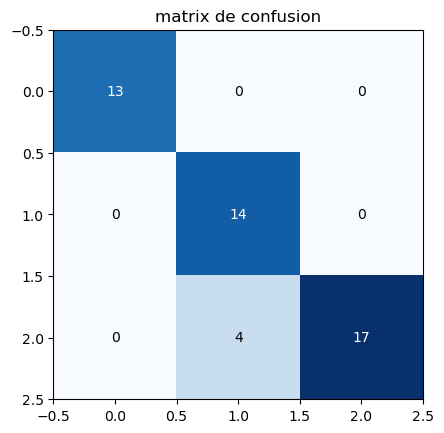

[INFO] accuracy: 0.9166666666666666
[INFO] precision: 0.9259259259259259


In [9]:
# clasificación
yh = modelo(x_test_tensor)
print(yh.shape)
acc,precc = confusion_matrix(yh,y_test_oh,n_out,plot=True,debug=False)
PrintLogLevel("INFO",f"accuracy: {acc}")
PrintLogLevel("INFO",f"precision: {precc}")